# Parsing Quantum ESPRESSO outputs with `qe-tools`

A short demo of [`qe-tools`](https://qe-tools.readthedocs.io/en/latest/) — the package pre-installed in the `qe` conda environment for parsing `pw.x` outputs.

## Loading a `pw.x` calculation

Point `PwOutput.from_files` at the stdout file of a finished calculation:

In [11]:
from qe_tools.outputs import PwOutput

pw_out = PwOutput.from_files(stdout='out/NaCl.ecut=20.out')

Total energies are in **Ry** by default.
Pass `to='pint'` to get a unit-decorated [`pint`](https://pint.readthedocs.io/en/stable/) `Quantity` instead of a bare float.

In [12]:
total_energy = pw_out.get_output('total_energy', to='pint')
total_energy

<Quantity(-117.087761, 'rydberg')>

You can then convert the value into any unit:

In [13]:
total_energy.to('eV')

<Quantity(-1593.06014, 'electron_volt')>

Use `.magnitude` to get the value as a float:

In [14]:
total_energy.to('eV').magnitude

-1593.0601428557525

## Tab completion

The outputs can also be obtained via tab completion from the `outputs` namespace:

In [15]:
pw_out.outputs.total_energy

-117.08776087

When working in an IDE that gives static code analysis (e.g. VSCode + Pylance), this approach also gives information on the type and a useful docstring.

## Plotting the convergence

Once you've run `script.sh` to run the convergence loop, you can use the following snippet to plot the total energy versus the wave function cutoffs:

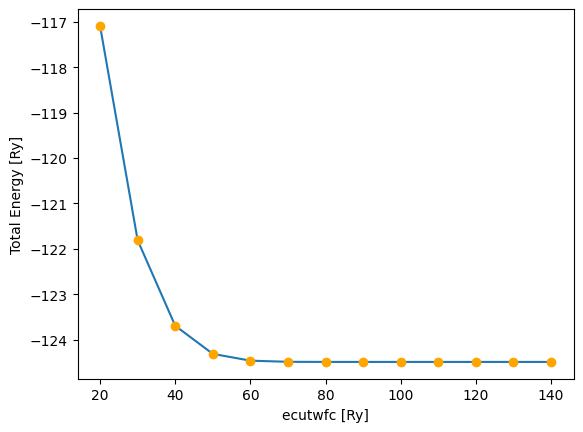

In [16]:
from pathlib import Path
import matplotlib.pyplot as plt

cutoffs = []
total_energies = []

for stdout in sorted(
    Path('out/').glob('*.out'),
    key=lambda filename: int(filename.stem.split('=')[1])
):
    pw_out = PwOutput.from_files(stdout=stdout)
    cutoffs.append(pw_out.outputs.parameters.ecutwfc)
    total_energies.append(pw_out.outputs.total_energy)

plt.plot(cutoffs, total_energies, 'o-', mfc='orange', mec='orange')
plt.xlabel('ecutwfc [Ry]')
plt.ylabel('Total Energy [Ry]');